# Comparing model Confidence with Tanimoto 

## v1

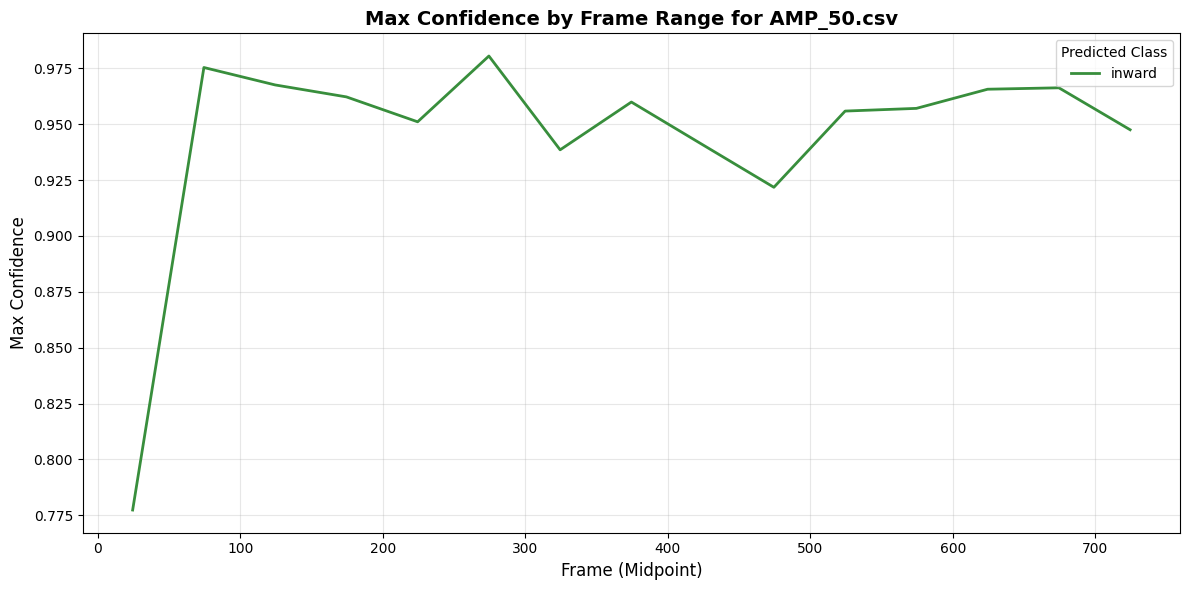

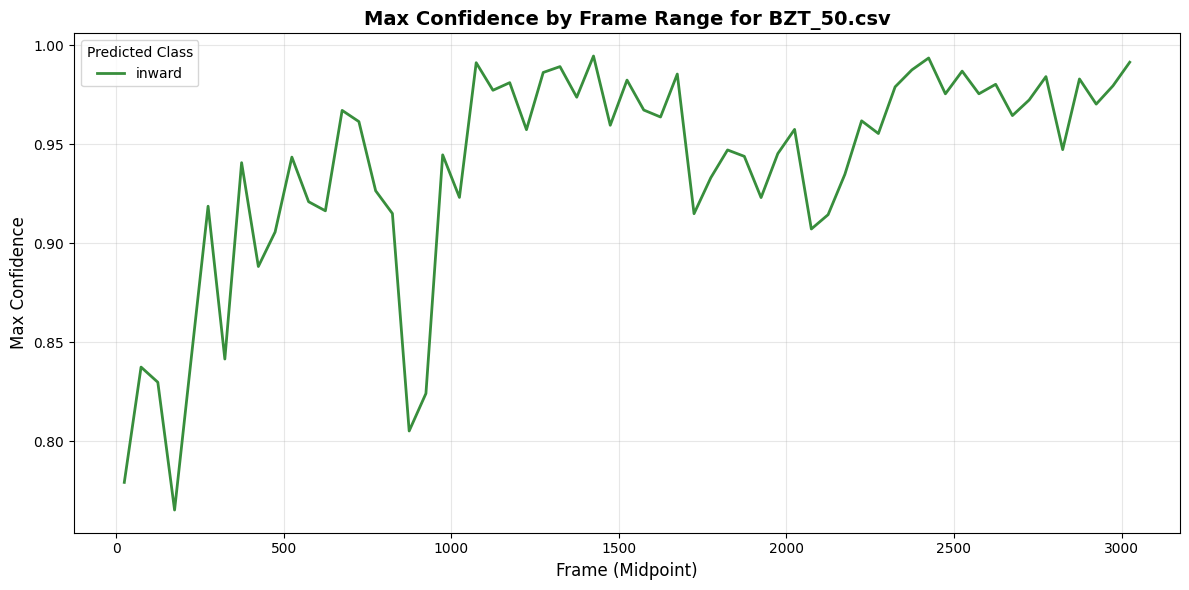

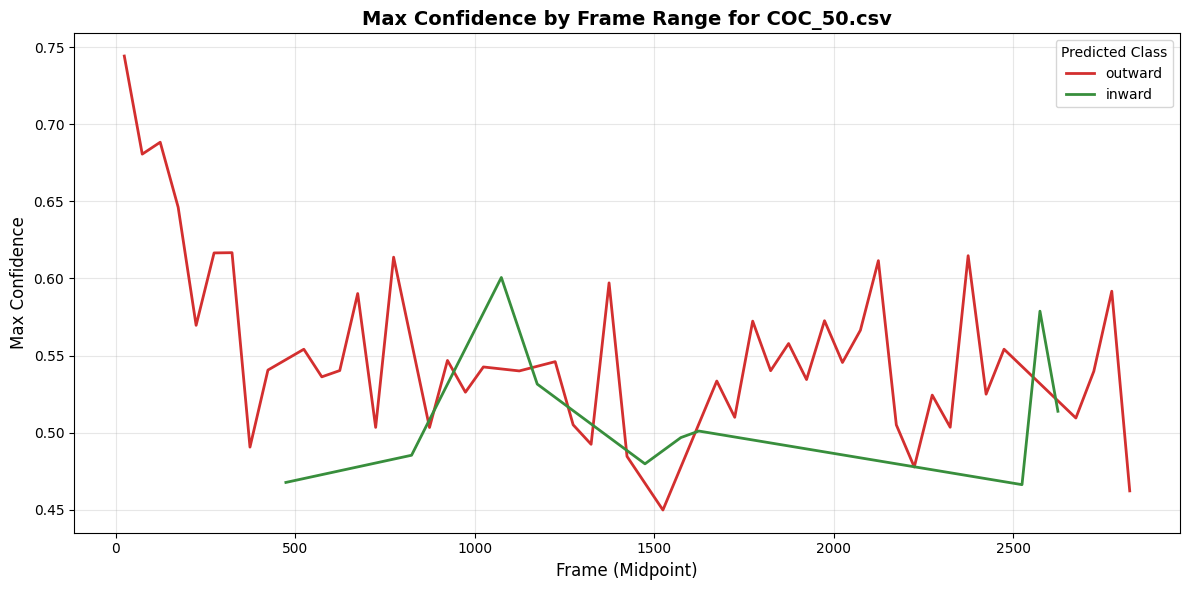

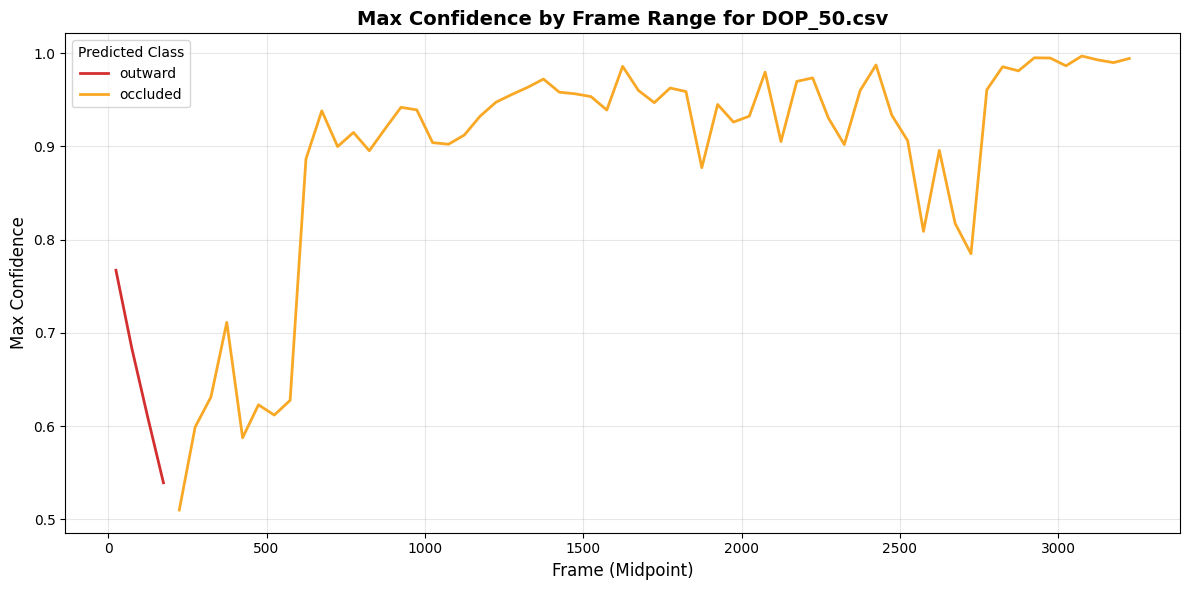

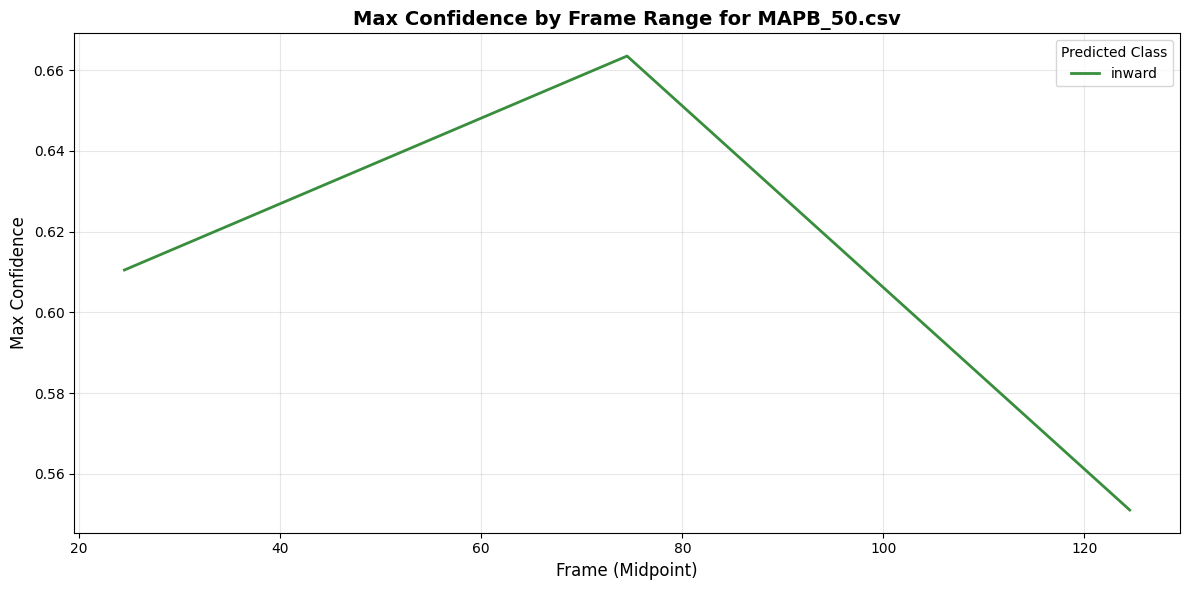

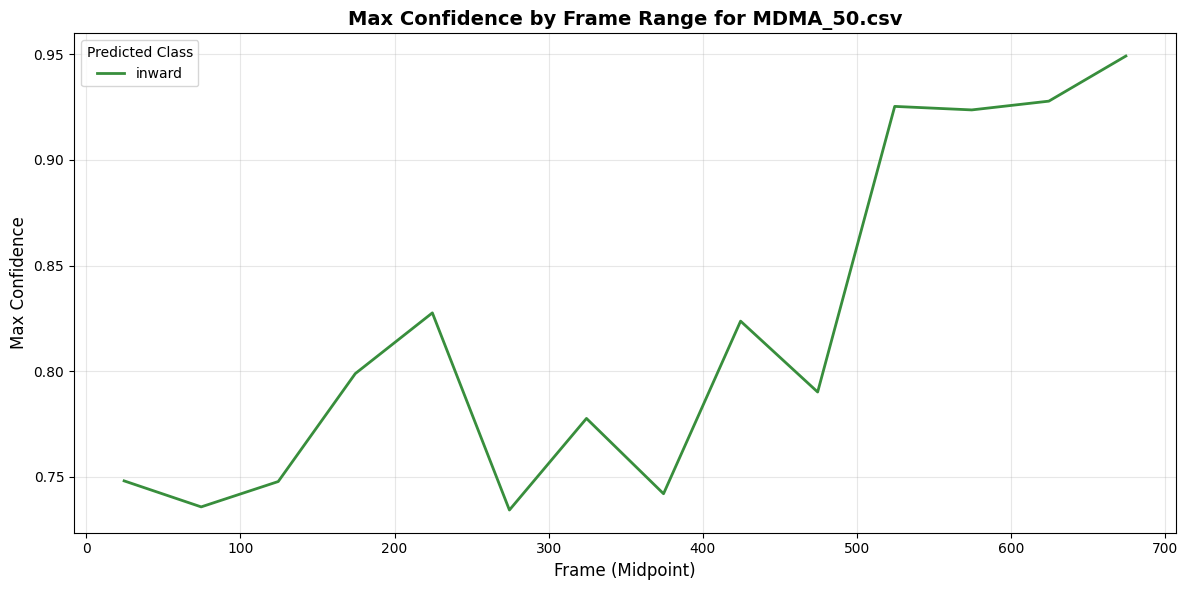

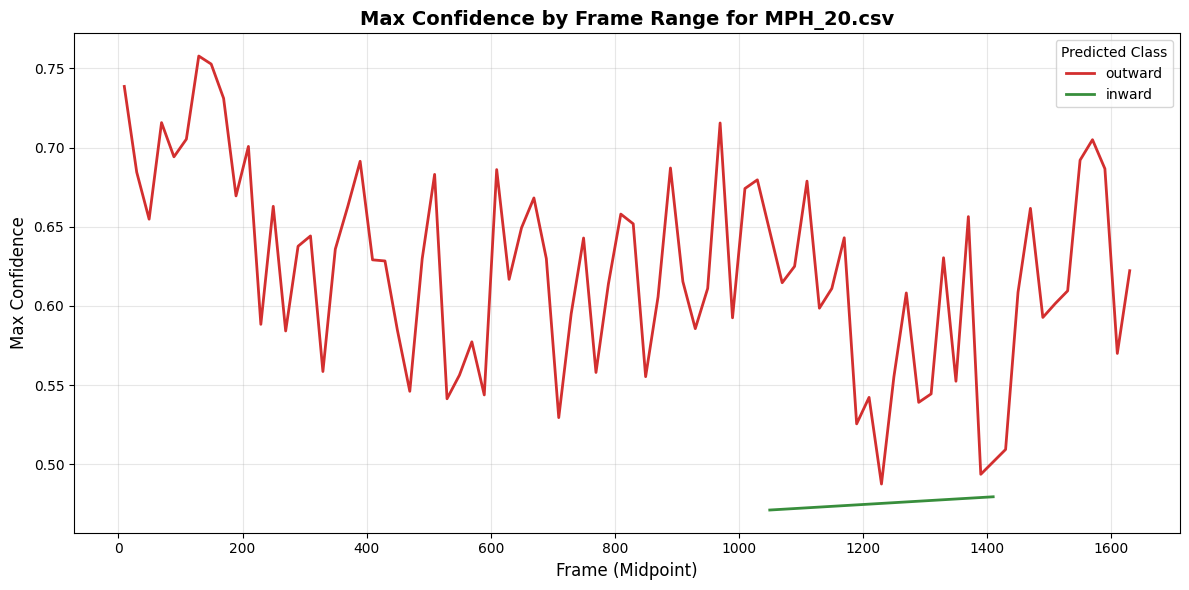

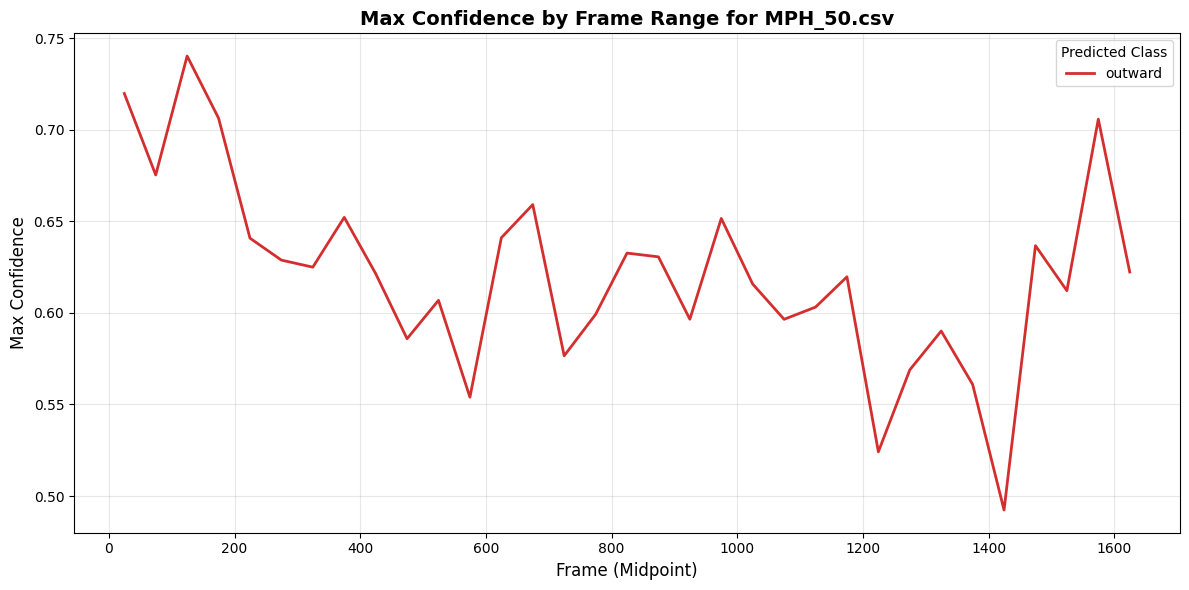

⚠️ Skipping predictions_cleaned_AMP.csv, required columns missing.
⚠️ Skipping predictions_cleaned_BZT.csv, required columns missing.
⚠️ Skipping predictions_cleaned_COC.csv, required columns missing.
⚠️ Skipping predictions_cleaned_DOP.csv, required columns missing.
⚠️ Skipping predictions_cleaned_MAPB.csv, required columns missing.
⚠️ Skipping predictions_cleaned_MDMA.csv, required columns missing.
⚠️ Skipping predictions_cleaned_MPH.csv, required columns missing.


In [6]:
# 📌 Import Required Libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Directory containing your CSV files
csv_dir = "Data/eval_CSV"

# Get list of CSV files in the directory
csv_files = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]

# Create colour palette for predicted class labels (expand as needed)
color_palette = {
    "occluded": "#f9a825",
    "outward": "#d32f2f",
    "inward": "#388e3c"
}

# Iterate through each CSV and plot
for csv_file in csv_files:
    file_path = os.path.join(csv_dir, csv_file)

    # Load CSV file
    df = pd.read_csv(file_path)

    # Check necessary columns
    required_cols = {"start_frame", "end_frame", "max_conf", "pred_class"}
    if not required_cols.issubset(df.columns):
        print(f"⚠️ Skipping {csv_file}, required columns missing.")
        continue

    # Calculate midpoint for frames
    df['mid_frame'] = (df['start_frame'] + df['end_frame']) / 2

    # Setup plot
    plt.figure(figsize=(12, 6))

    # Plot each predicted class separately to maintain distinct colours
    for label in df['pred_class'].unique():
        label_df = df[df['pred_class'] == label]
        plt.plot(
            label_df['mid_frame'],
            label_df['max_conf'],
            label=label,
            color=color_palette.get(label, '#333333'),  # default colour if not in palette
            linewidth=2
        )

    # Enhancements for readability
    plt.title(f"Max Confidence by Frame Range for {csv_file}", fontsize=14, fontweight='bold')
    plt.xlabel("Frame (Midpoint)", fontsize=12)
    plt.ylabel("Max Confidence", fontsize=12)
    plt.legend(title="Predicted Class")
    plt.grid(alpha=0.3)

    # Show plot
    plt.tight_layout()
    plt.show()


## v2

⚠️ Skipping AMP_50.csv, required columns missing.
⚠️ Skipping BZT_50.csv, required columns missing.
⚠️ Skipping COC_50.csv, required columns missing.
⚠️ Skipping DOP_50.csv, required columns missing.
⚠️ Skipping MAPB_50.csv, required columns missing.
⚠️ Skipping MDMA_50.csv, required columns missing.
⚠️ Skipping MPH_50.csv, required columns missing.


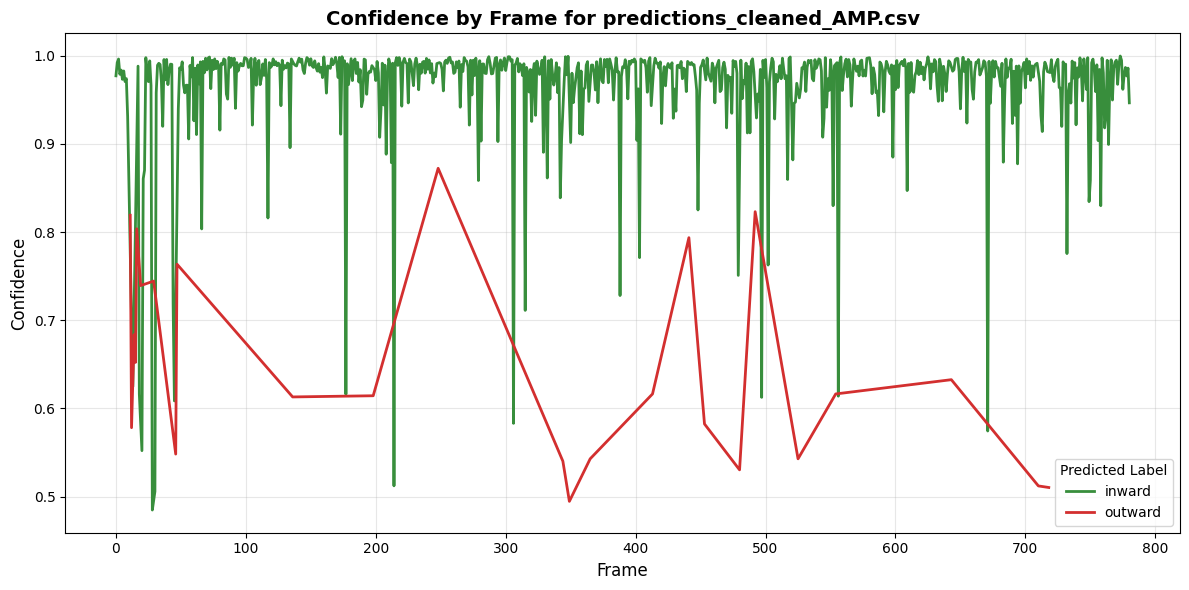

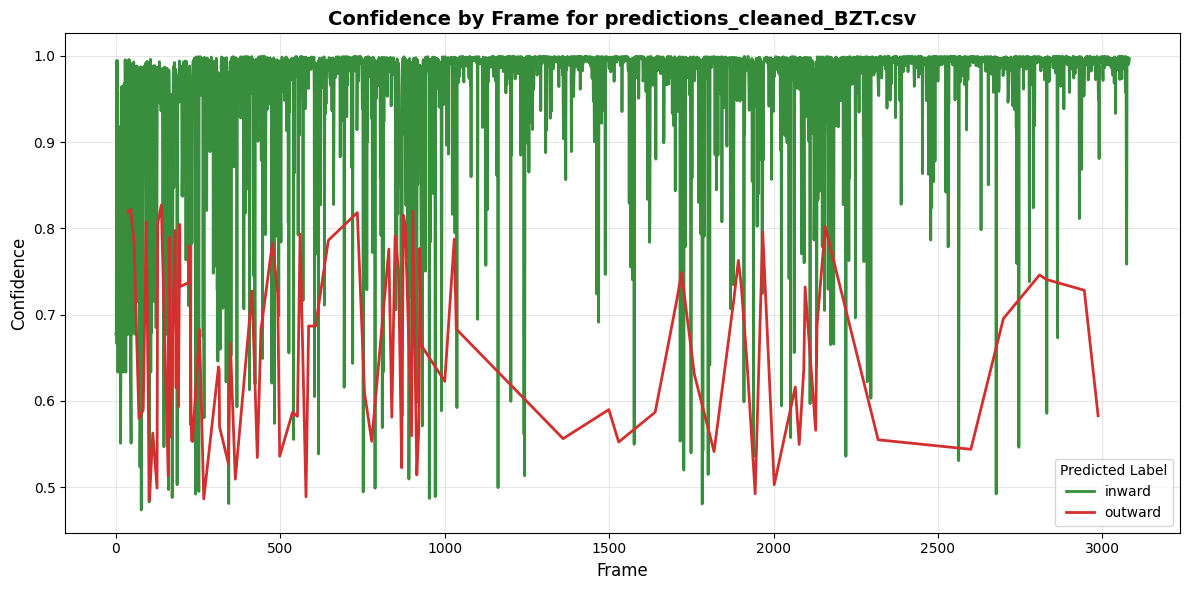

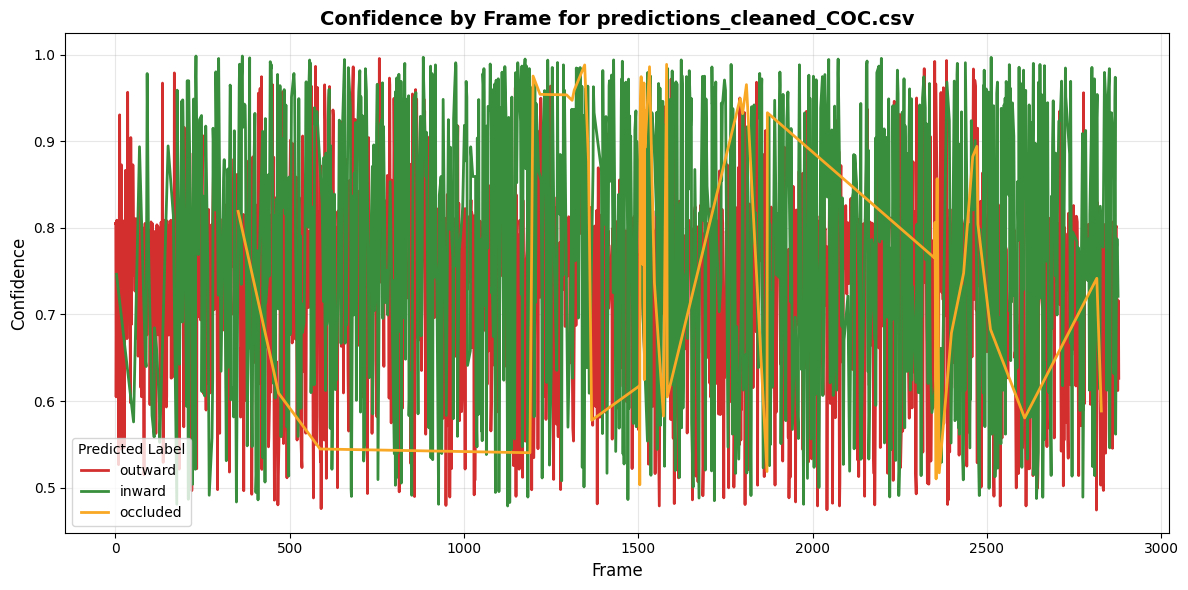

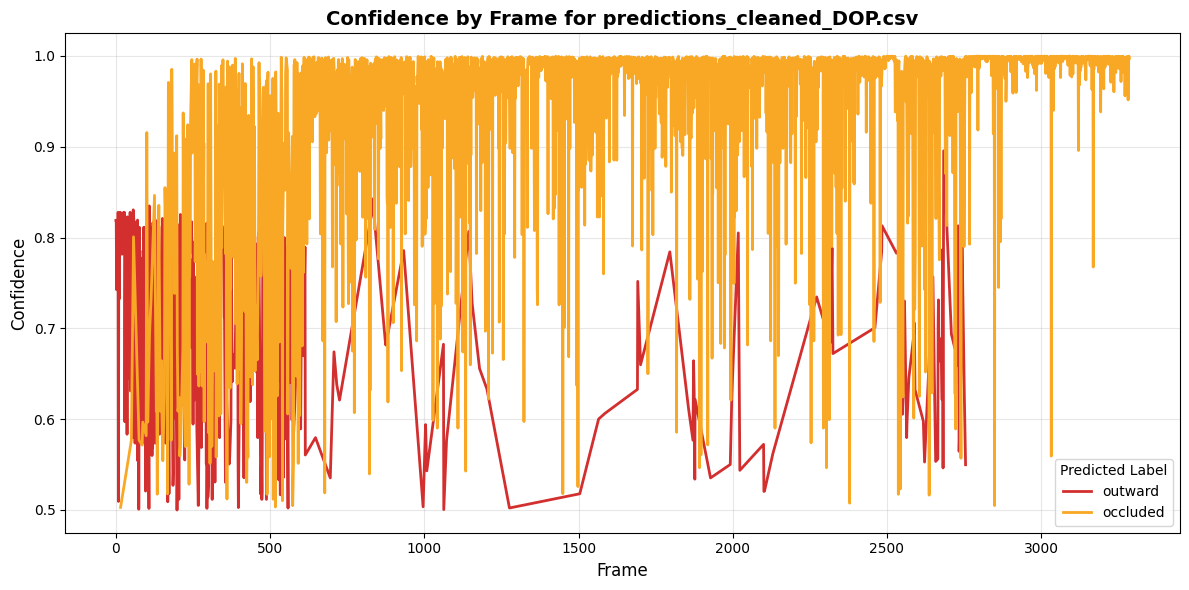

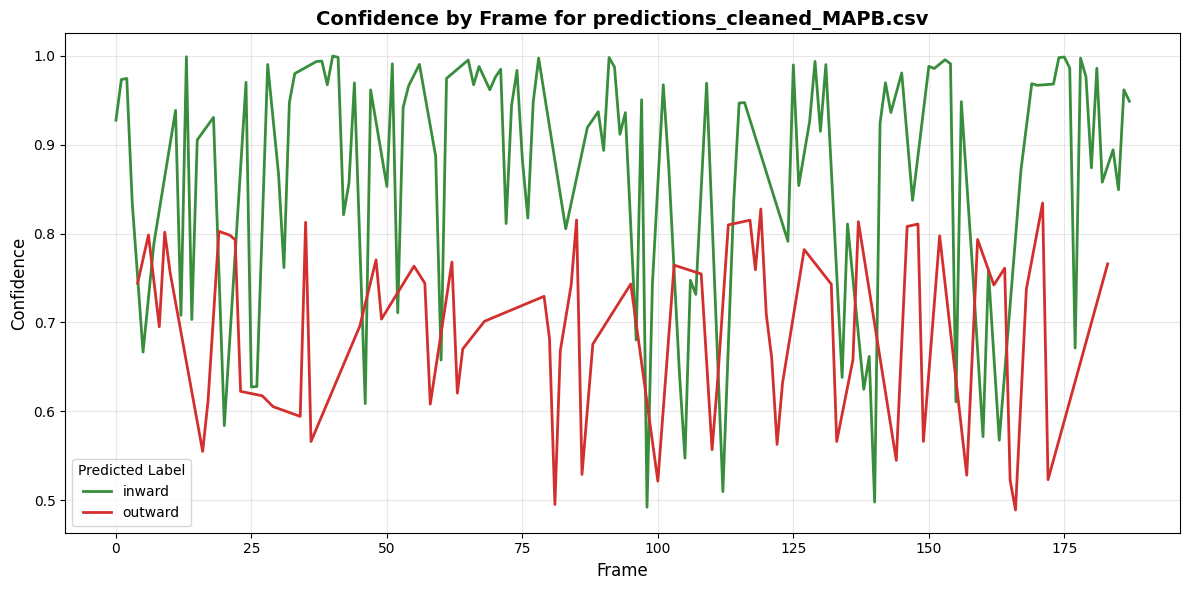

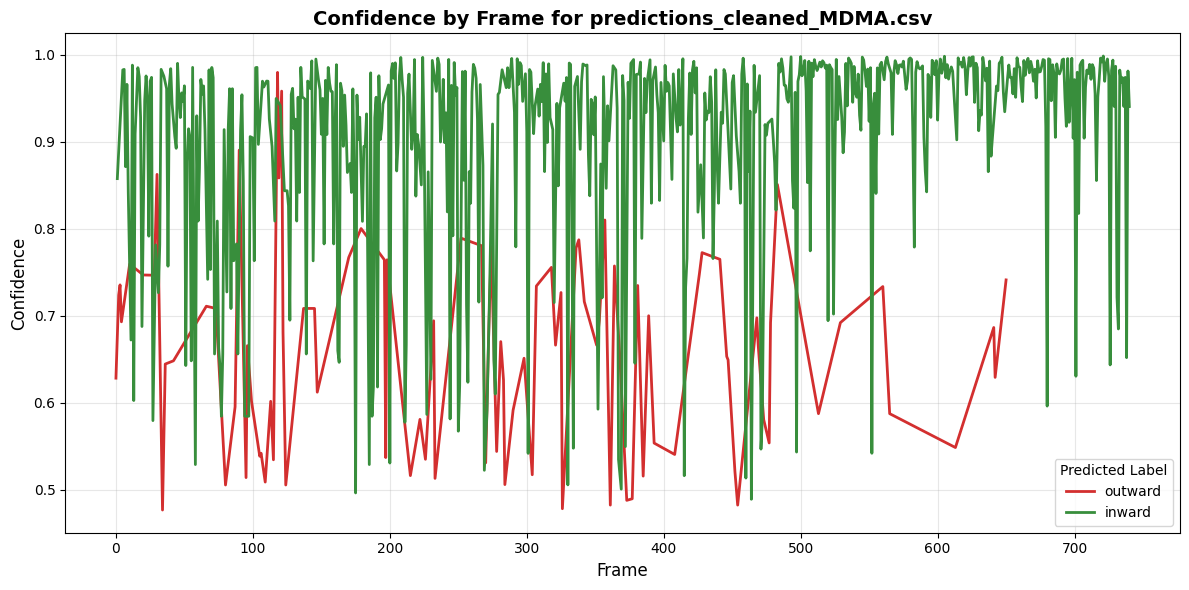

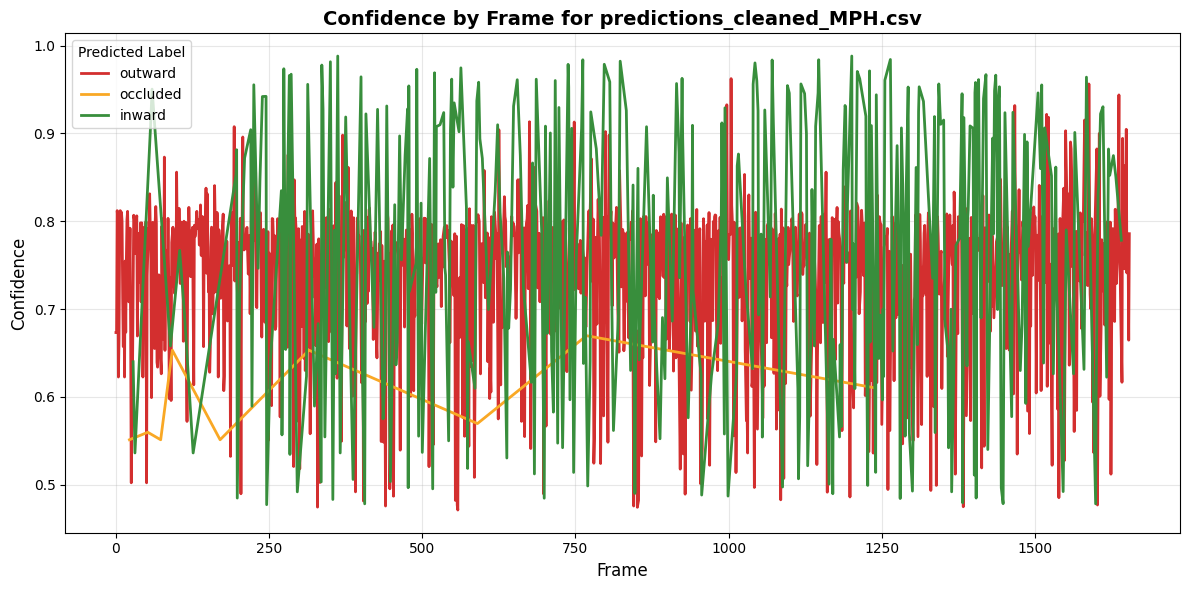

In [5]:
# 📌 Import Required Libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Directory containing your CSV files
csv_dir = "Data/eval_CSV"

# Get list of CSV files in the directory
csv_files = [f for f in os.listdir(csv_dir) if f.endswith('.csv')]

# Create colour palette for predicted labels (expand as needed)
color_palette = {
    "occluded": "#f9a825",
    "outward": "#d32f2f",
    "inward": "#388e3c"
}

# Iterate through each CSV and plot
for csv_file in csv_files:
    file_path = os.path.join(csv_dir, csv_file)

    # Load CSV file
    df = pd.read_csv(file_path)

    # Check necessary columns
    if not {"Frame", "Confidence", "Predicted"}.issubset(df.columns):
        print(f"⚠️ Skipping {csv_file}, required columns missing.")
        continue

    # Setup plot
    plt.figure(figsize=(12, 6))

    # Plot each predicted label separately to maintain distinct colours
    for label in df['Predicted'].unique():
        label_df = df[df['Predicted'] == label]
        plt.plot(
            label_df['Frame'],
            label_df['Confidence'],
            label=label,
            color=color_palette.get(label, '#333333'),  # default colour if not in palette
            linewidth=2
        )

    # Enhancements for readability
    plt.title(f"Confidence by Frame for {csv_file}", fontsize=14, fontweight='bold')
    plt.xlabel("Frame", fontsize=12)
    plt.ylabel("Confidence", fontsize=12)
    plt.legend(title="Predicted Label")
    plt.grid(alpha=0.3)

    # Show plot
    plt.tight_layout()
    plt.show()

## v3

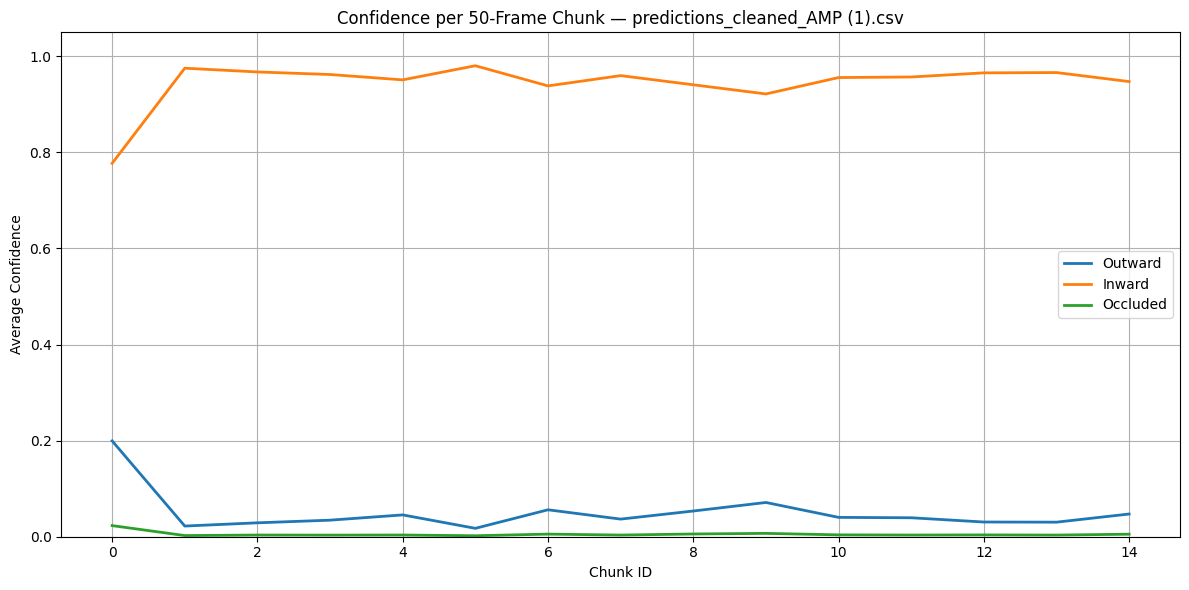

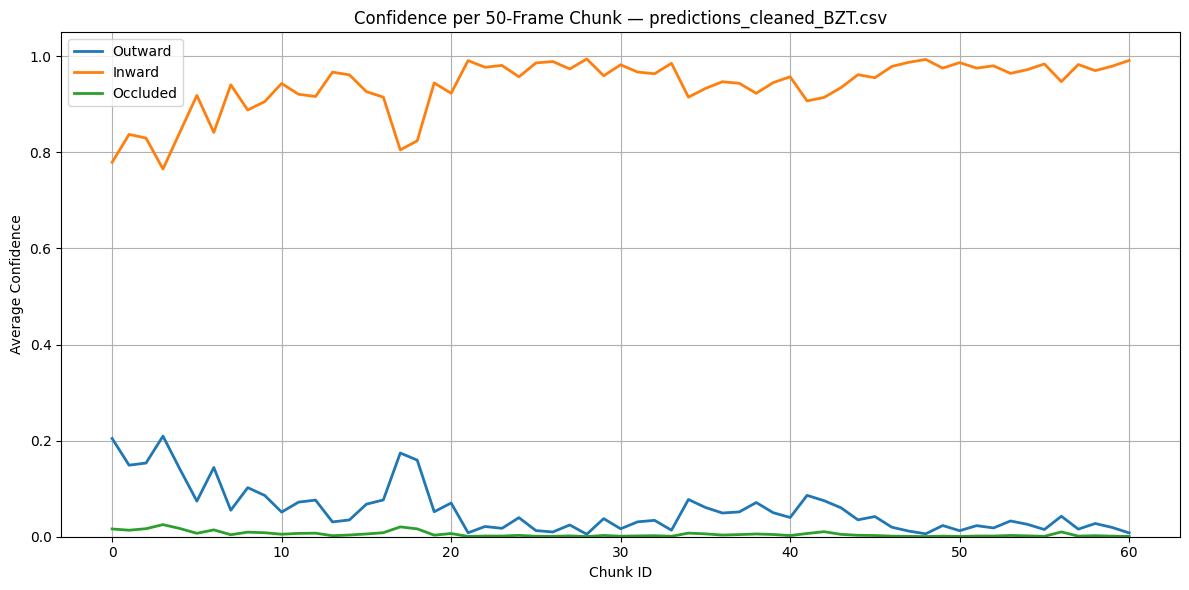

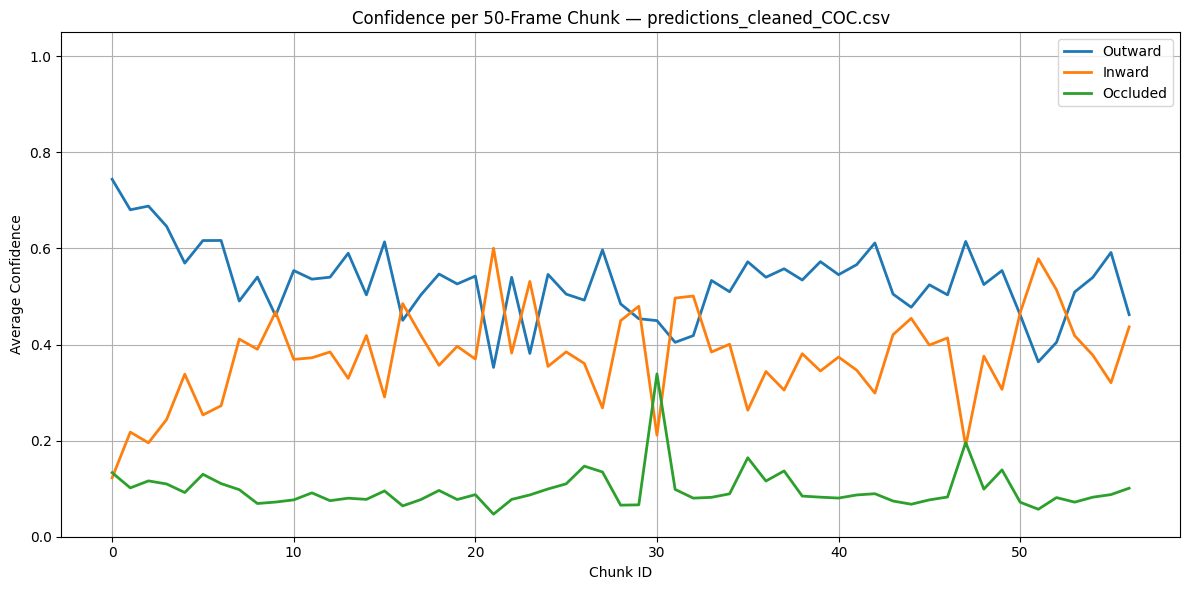

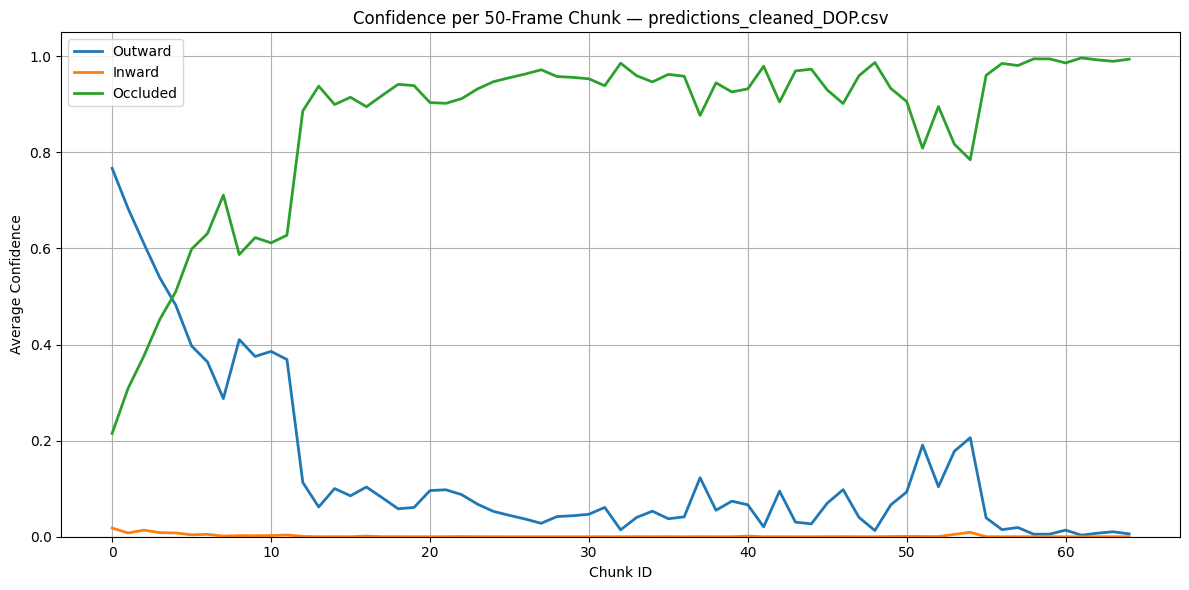

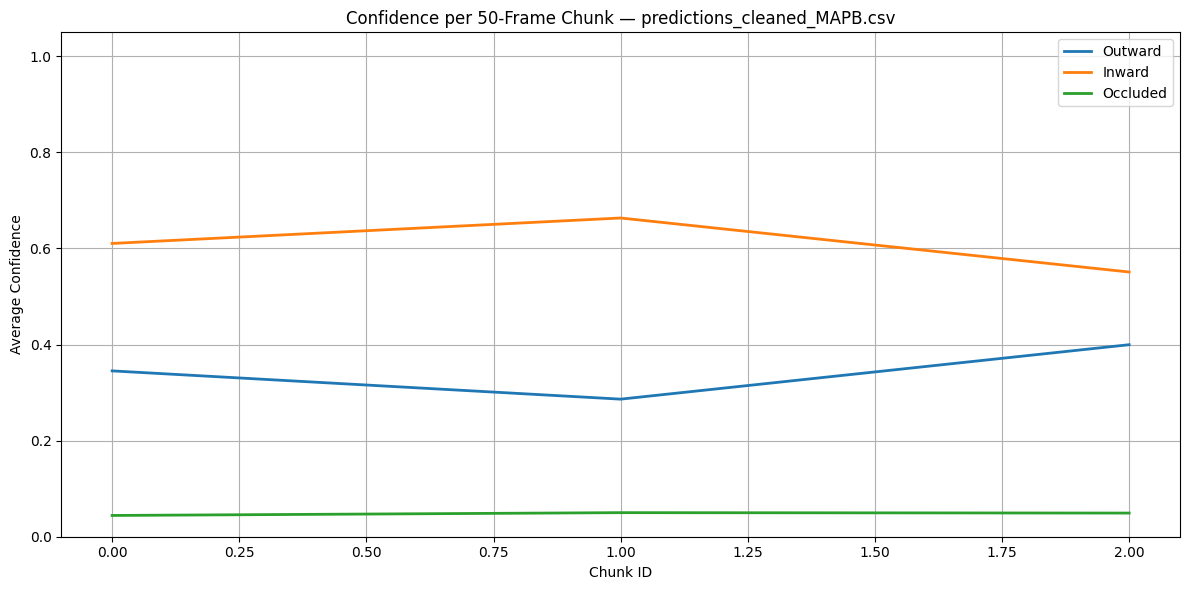

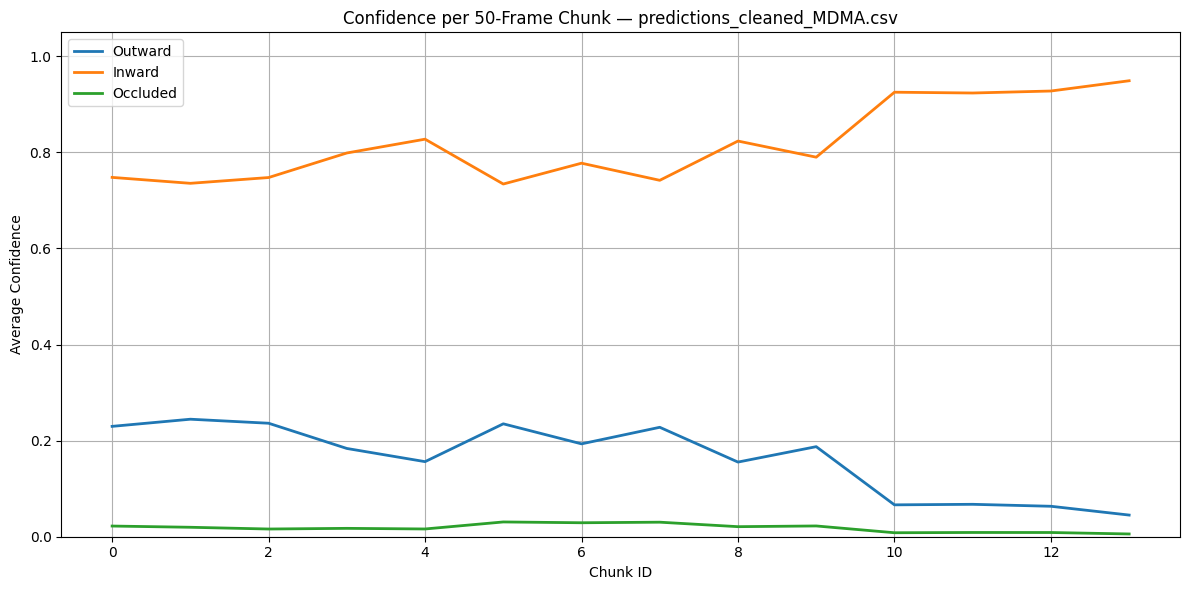

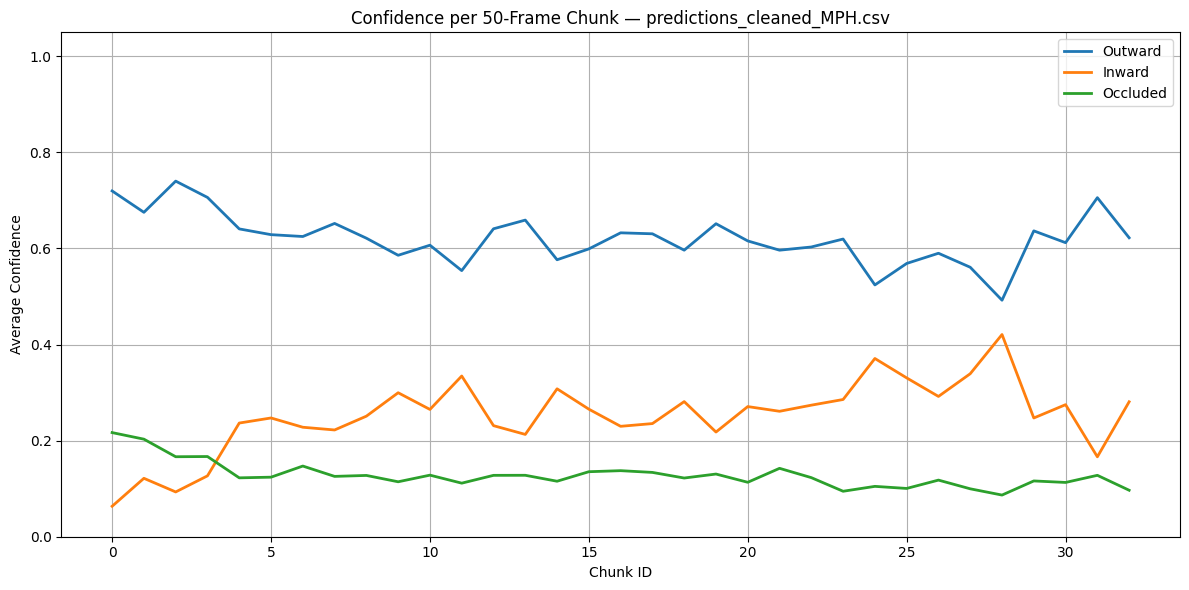

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Path to your CSV folder
csv_dir = "Data/eval_CSV"
chunk_size = 50

# Get list of CSV files
csv_files = [f for f in os.listdir(csv_dir) if f.endswith(".csv")]

# Loop through files
for file in csv_files:
    path = os.path.join(csv_dir, file)
    df = pd.read_csv(path)

    # Check necessary columns
    required_cols = ["Frame", "score_outward", "score_inward", "score_occluded"]
    if not all(col in df.columns for col in required_cols):
        print(f"⚠️ Skipping {file} (missing required columns)")
        continue

    # Sort by frame (just in case)
    df = df.sort_values("Frame").reset_index(drop=True)

    # Create chunks
    num_chunks = len(df) // chunk_size
    chunked = []
    for i in range(num_chunks):
        chunk = df.iloc[i * chunk_size:(i + 1) * chunk_size]
        chunked.append({
            "chunk_id": i,
            "avg_outward": chunk["score_outward"].mean(),
            "avg_inward": chunk["score_inward"].mean(),
            "avg_occluded": chunk["score_occluded"].mean(),
        })

    # Create dataframe from chunks
    chunk_df = pd.DataFrame(chunked)

    # Plot
    plt.figure(figsize=(12, 6))
    plt.plot(chunk_df["chunk_id"], chunk_df["avg_outward"], label="Outward", linewidth=2)
    plt.plot(chunk_df["chunk_id"], chunk_df["avg_inward"], label="Inward", linewidth=2)
    plt.plot(chunk_df["chunk_id"], chunk_df["avg_occluded"], label="Occluded", linewidth=2)
    plt.title(f"Confidence per 50-Frame Chunk — {file}")
    plt.xlabel("Chunk ID")
    plt.ylabel("Average Confidence")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
